In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [3]:
image_cut = image[55:155, 0:1890]
image_error_cut = image_error[55:155, 0:1890]

Text(0.5, 0, 'wavelenght')

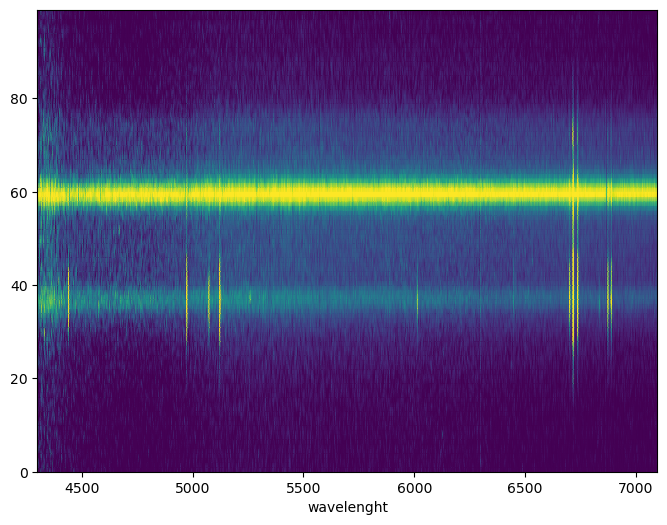

In [4]:
wavelenghts = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.figure(figsize=(8,6))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [5]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [6]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, params):
    """ Profilo Sérsic 1D centrato in x_0 """
    I_e, r_e, n, x_0 = params
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
    
def sersic_1d_convolved(x, params):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, params)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

def model_convolved(x, params1, params2, params3, params4):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, params1) +
        sersic_1d(x_hr, params2) +
        sersic_1d(x_hr, params3) +
        sersic_1d(x_hr, params4)
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

In [7]:
def plot_sigma_HA(sigma_extraction, x_axes, fit, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(xgrid, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].plot(x_axes, radial_profile, label='Data', zorder=3)
    ax[0].plot(xgrid, y_fit, 'r', label='Total Fit', zorder=3)
    
    colors = ['b', 'g', 'm', 'orange']  
    components = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
    
    for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(xgrid, np.array(fit[comp_name]))
        ax[0].plot(xgrid, y_comp, '--', color=color,  
                  label=f'Sérsic {i+1}')
        
        params = fit[comp_name]
        center = params[3] 

        left_region_sx = center - sigma_extraction * sigma -2*sigma_extraction * sigma 
        
        left_region_c = center - sigma_extraction * sigma 
        right_region_c = center + sigma_extraction * sigma 
 
        right_region_dx = center + sigma_extraction * sigma + 2*sigma_extraction * sigma
        
        ax[0].axvspan(left_region_sx, left_region_c, alpha=0.15, color=color, zorder=1)
        ax[0].axvspan(left_region_c, right_region_c, alpha=0.15, color=color, zorder=1)
        ax[0].axvspan(right_region_c, right_region_dx, alpha=0.15, color=color, zorder=1)
        
        ax[0].axvline(left_region_sx, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(left_region_c, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(right_region_c, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(right_region_dx, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Genera automaticamente il titolo
    sigma_text = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}"
    title = f"Radial profile H$\\alpha$ with {sigma_text}$\\sigma$ Spectral Extraction Regions"
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    ax[0].set_ylim(0, 12.5)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"Halpha_{sigma_str}sigma.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

In [8]:
seeing = 3.174
sigma = seeing / 2.35 

## Halpha

Text(0.5, 1.0, 'H$\\alpha$')

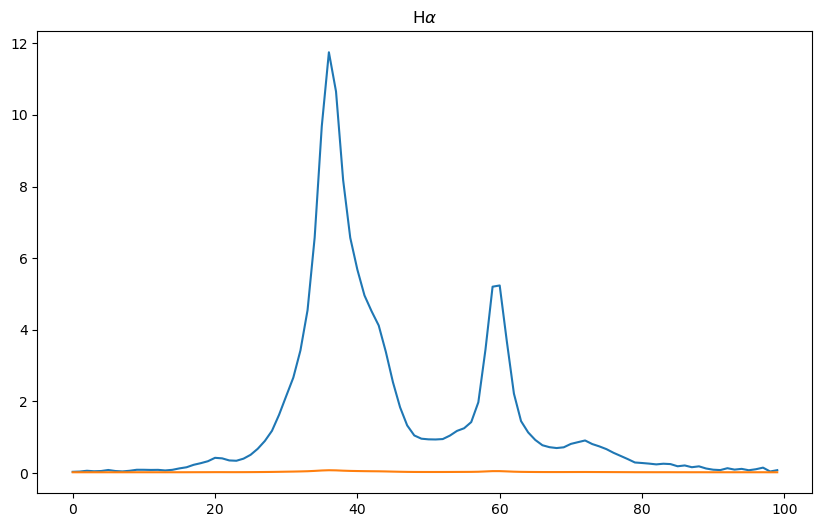

In [9]:
mask_HA = (wavelenghts > l_HA-8)*(wavelenghts < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

  Unnamed: 0  Component 1  Component 2  Component 3  Component 4
0        I_e       1.0081       0.1652       0.2287       0.0541
1        r_e       8.0499      12.7280       7.6540      29.9048
2          n       1.7757       2.0386       2.6117       1.6698
3        x_0      36.1993      42.1723      59.5634      72.0558
Plot salvato come: ./Halpha_1sigma.png
Plot salvato come: ./Halpha_1p5sigma.png
Plot salvato come: ./Halpha_2sigma.png
Plot salvato come: ./Halpha_3sigma.png


(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Radial profile H$\\alpha$ with 3$\\sigma$ Spectral Extraction Regions'}, ylabel='Flux [$10^{-16}$ erg/(cm$^2$ s Å)]'>,
        <Axes: xlabel='Pixel', ylabel='$\\chi$'>], dtype=object))

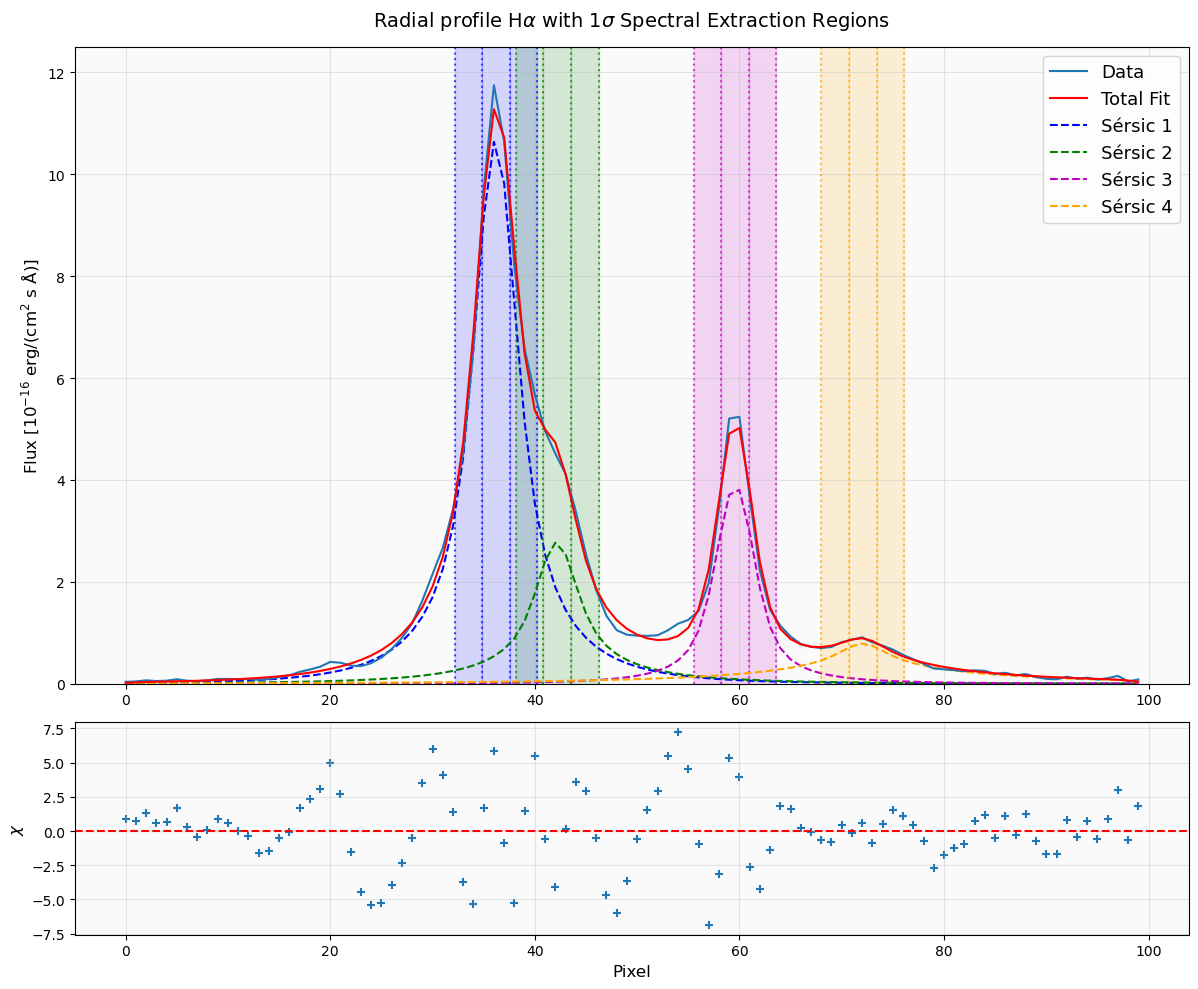

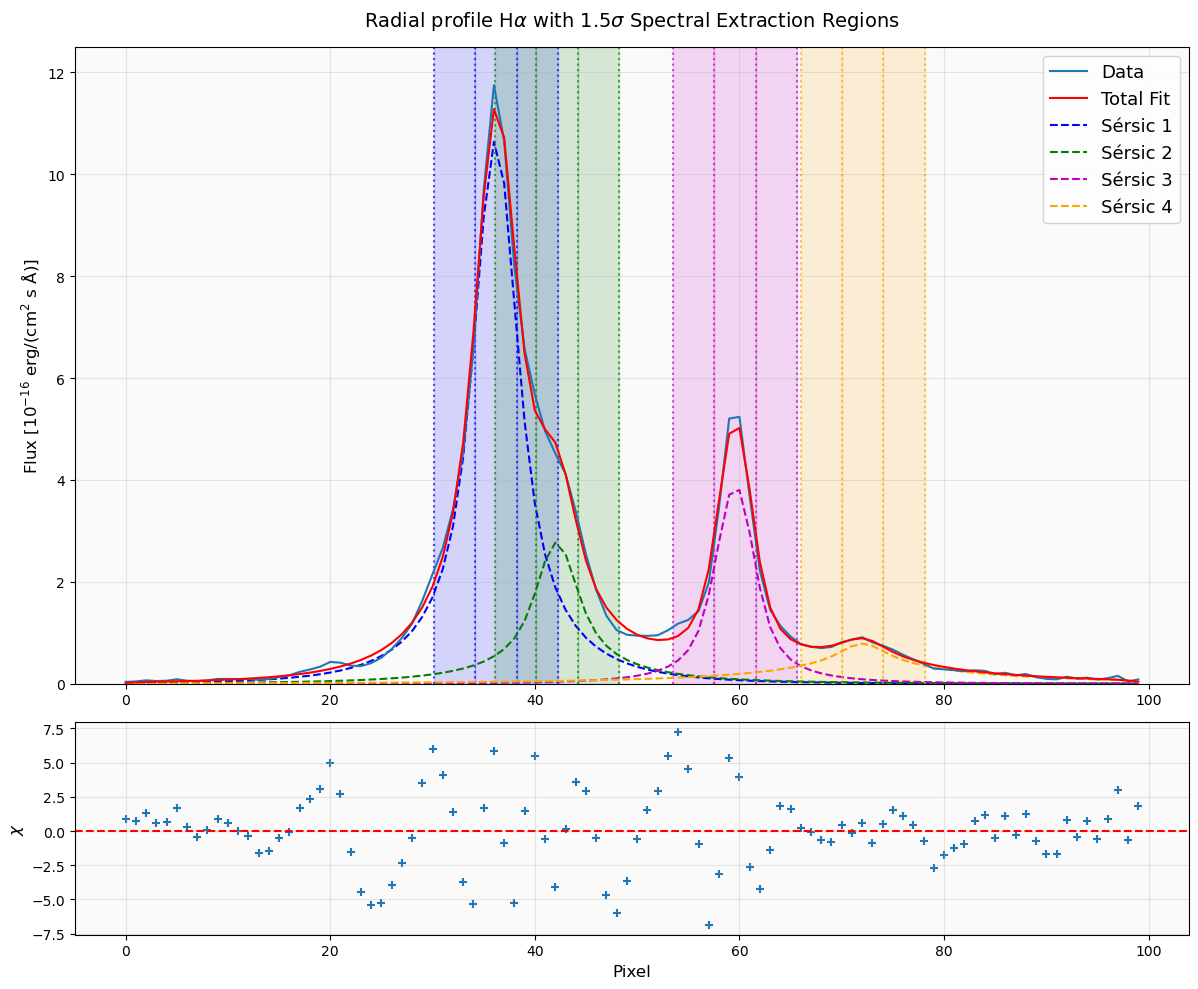

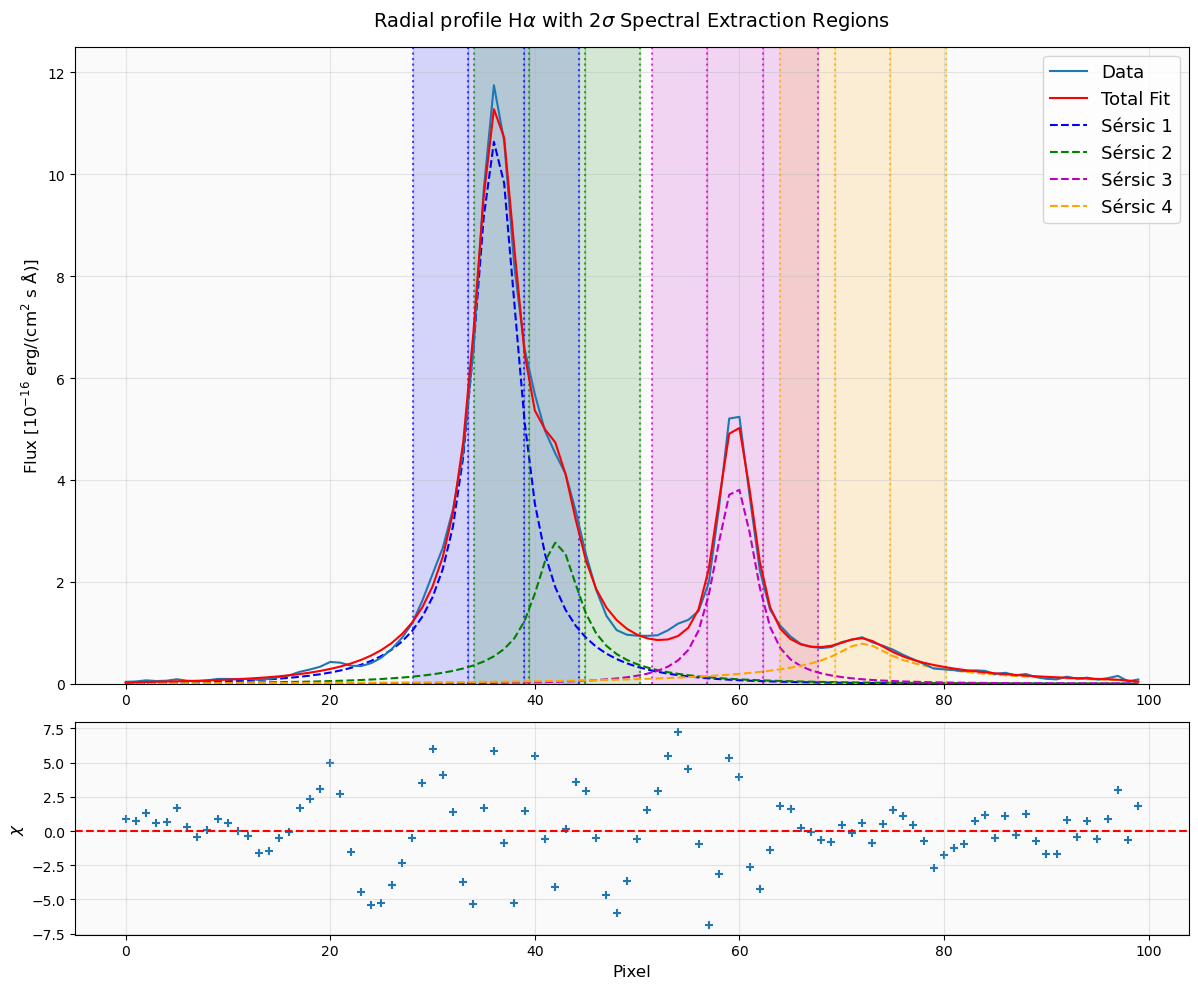

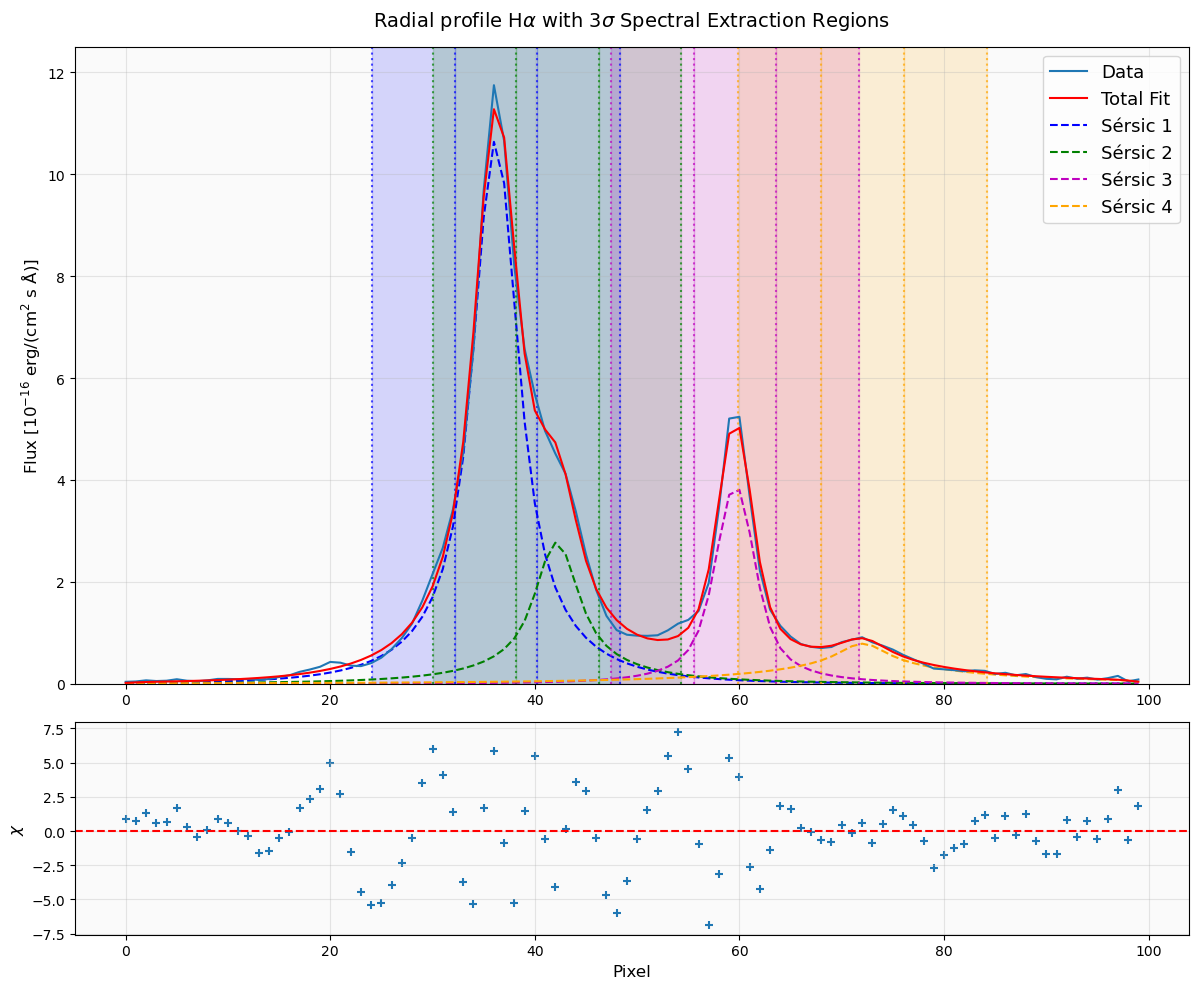

In [12]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv")
print(fit_HA)
plot_sigma_HA(1.0, x_axes, fit_HA, radial_profile_HA, radial_profile_error_HA, save_plot=True, output_dir="./")
plot_sigma_HA(1.5, x_axes, fit_HA, radial_profile_HA, radial_profile_error_HA, save_plot=True, output_dir="./")
plot_sigma_HA(2.0, x_axes, fit_HA, radial_profile_HA, radial_profile_error_HA, save_plot=True, output_dir="./")
plot_sigma_HA(3.0, x_axes, fit_HA, radial_profile_HA, radial_profile_error_HA, save_plot=True, output_dir="./")

In [ ]:
def plot_2xt_HA(x_axes, fit, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(xgrid, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].plot(x_axes, radial_profile, label='Data', zorder=3)
    ax[0].plot(xgrid, y_fit, 'r', label='Total Fit', zorder=3)
    for i in range(20):
        x_min = 10 + i * 4
        x_max = x_min + 4
        ax[0].axvspan(x_min, x_max, alpha=0.15, zorder=1)
        ax[0].axvline(x_min, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(x_max, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    #ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    ax[0].set_ylim(0, 12.5)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"Halpha_{sigma_str}sigma.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

plot_2xt_HA(x_axes, fit_HA, radial_profile_HA, radial_profile_error_HA, save_plot=False, output_dir="./")

(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: ylabel='Flux [$10^{-16}$ erg/(cm$^2$ s Å)]'>,
        <Axes: xlabel='Pixel', ylabel='$\\chi$'>], dtype=object))

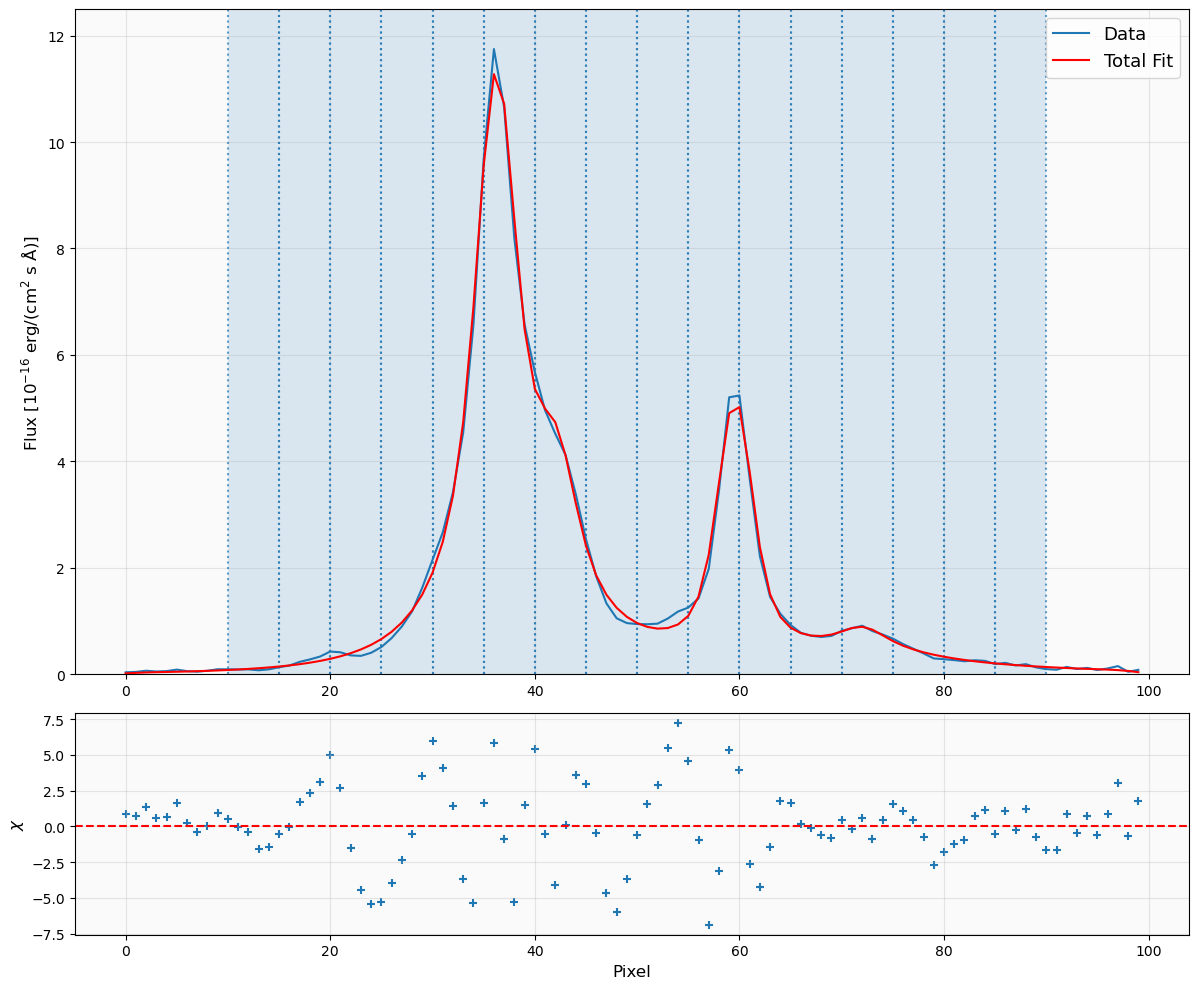

In [12]:
def plot_2xt_HA(x_axes, fit, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(xgrid, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].plot(x_axes, radial_profile, label='Data', zorder=3)
    ax[0].plot(xgrid, y_fit, 'r', label='Total Fit', zorder=3)
    for i in range(2, 18):
        x_min = i *5
        x_max = x_min + 5
        ax[0].axvspan(x_min, x_max, alpha=0.15, zorder=1)
        ax[0].axvline(x_min, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(x_max, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    #ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    ax[0].set_ylim(0, 12.5)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"Halpha_{sigma_str}sigma.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

plot_2xt_HA(x_axes, fit_HA, radial_profile_HA, radial_profile_error_HA, save_plot=False, output_dir="./")

## Hbeta

Text(0.5, 1.0, 'H$\\beta$')

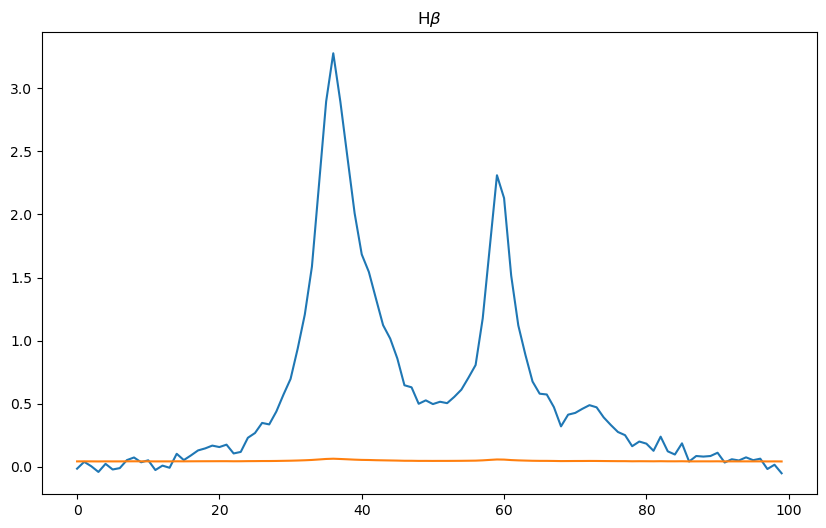

In [13]:
mask_HB = (wavelenghts > l_HB-8)*(wavelenghts < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [14]:
def plot_sigma_HB(sigma_extraction, x_axes, fit, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(xgrid, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].plot(x_axes, radial_profile, label='Data', zorder=3)
    ax[0].plot(xgrid, y_fit, 'r', label='Total Fit', zorder=3)
    
    colors = ['b', 'g', 'm', 'orange']  
    components = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
    
    for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(xgrid, np.array(fit[comp_name]))
        ax[0].plot(xgrid, y_comp, '--', color=color,  
                  label=f'Sérsic {i+1}')
        
        params = fit[comp_name]
        center = params[3] 
        
        left_region = center - sigma_extraction * sigma 
        right_region = center + sigma_extraction * sigma 
        
        ax[0].axvspan(left_region, right_region, alpha=0.15, color=color, zorder=1)
        
        ax[0].axvline(left_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(right_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Genera automaticamente il titolo
    sigma_text = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}"
    title = f"Radial profile H$\\beta$ with {sigma_text}$\\sigma$ Spectral Extraction Regions"
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    ax[0].set_ylim(0, 12.5)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"Hbeta_{sigma_str}sigma.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_11440\1846438079.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center = params[3]


Plot salvato come: ./Hbeta_1sigma.png
Plot salvato come: ./Hbeta_2sigma.png
Plot salvato come: ./Hbeta_3sigma.png


(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Radial profile H$\\beta$ with 3$\\sigma$ Spectral Extraction Regions'}, ylabel='Flux [$10^{-16}$ erg/(cm$^2$ s Å)]'>,
        <Axes: xlabel='Pixel', ylabel='$\\chi$'>], dtype=object))

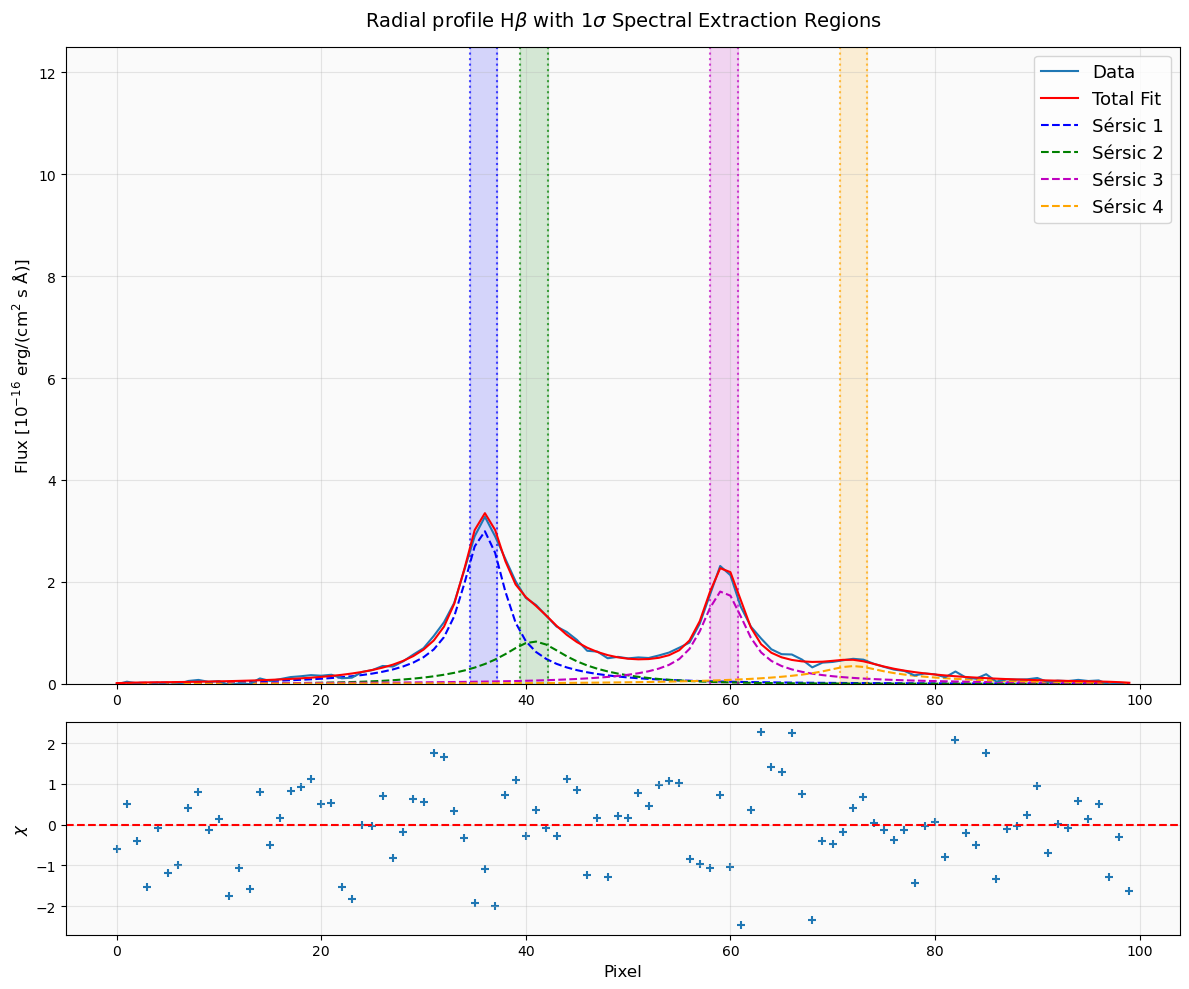

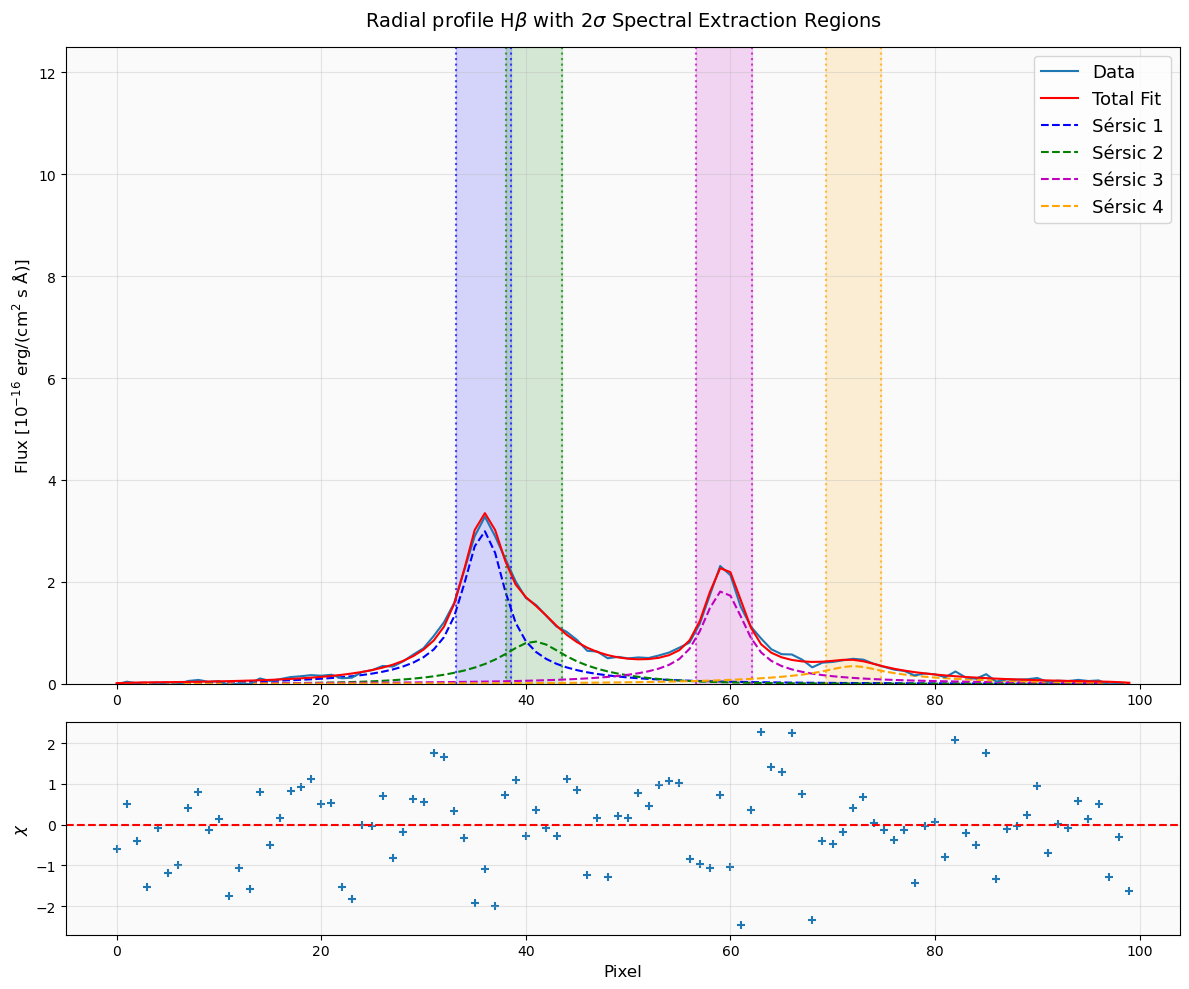

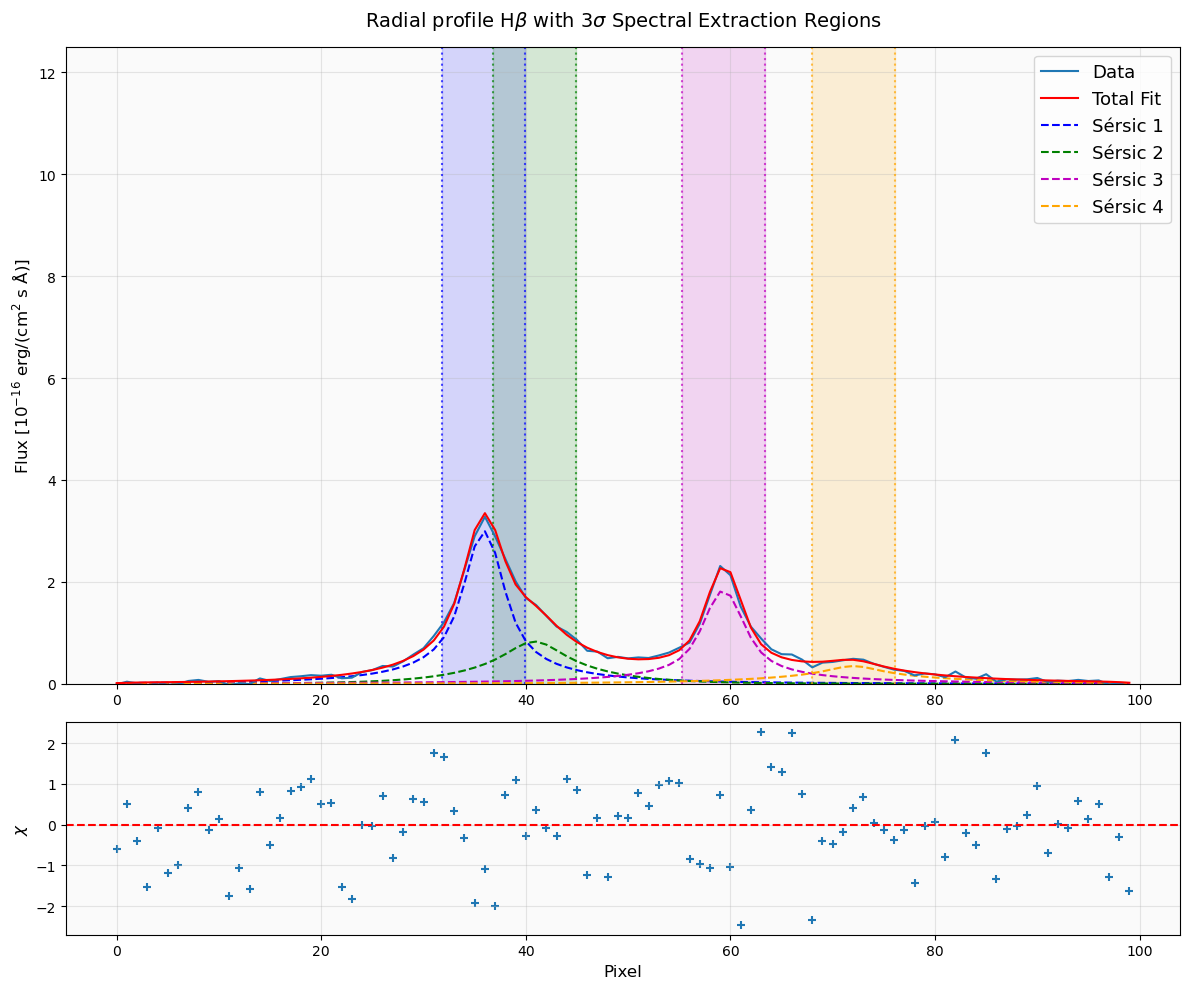

In [15]:
fit_HB = pd.read_csv("Hbeta_fit.csv", index_col = 0)
plot_sigma_HB(1.0, x_axes, fit_HB, radial_profile_HB, radial_profile_error_HB, save_plot=True, output_dir="./")
plot_sigma_HB(2.0, x_axes, fit_HB, radial_profile_HB, radial_profile_error_HB, save_plot=True, output_dir="./")
plot_sigma_HB(3.0, x_axes, fit_HB, radial_profile_HB, radial_profile_error_HB, save_plot=True, output_dir="./")

## NII

Text(0.5, 1.0, '[NII]')

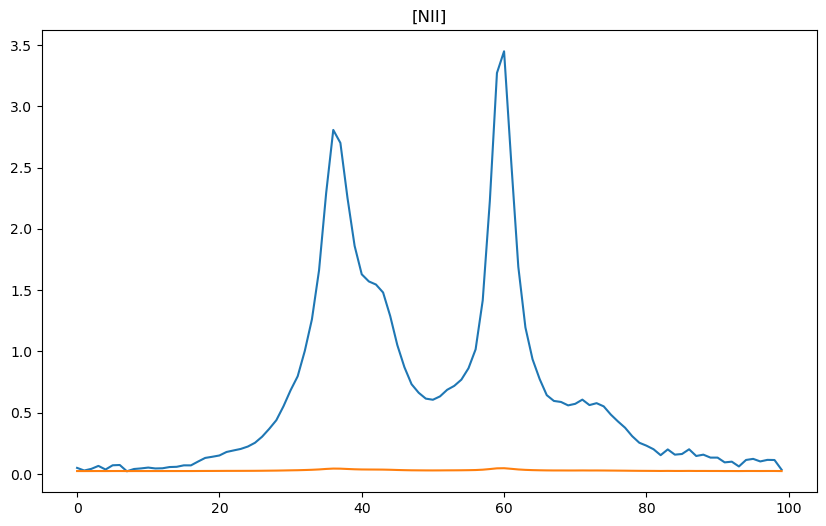

In [16]:
mask_NII = (wavelenghts > l_NII-8)*(wavelenghts < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [17]:
def plot_sigma_NII(sigma_extraction, x_axes, fit, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(xgrid, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].plot(x_axes, radial_profile, label='Data', zorder=3)
    ax[0].plot(xgrid, y_fit, 'r', label='Total Fit', zorder=3)
    
    colors = ['b', 'g', 'm', 'orange']  
    components = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
    
    for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(xgrid, np.array(fit[comp_name]))
        ax[0].plot(xgrid, y_comp, '--', color=color,  
                  label=f'Sérsic {i+1}')
        
        params = fit[comp_name]
        center = params[3] 
        
        left_region = center - sigma_extraction * sigma 
        right_region = center + sigma_extraction * sigma 
        
        ax[0].axvspan(left_region, right_region, alpha=0.15, color=color, zorder=1)
        
        ax[0].axvline(left_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(right_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Genera automaticamente il titolo
    sigma_text = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}"
    title = f"Radial profile [NII] with {sigma_text}$\\sigma$ Spectral Extraction Regions"
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    ax[0].set_ylim(0, 12.5)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"NII_{sigma_str}sigma.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_11440\1788337806.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center = params[3]


Plot salvato come: ./NII_1sigma.png
Plot salvato come: ./NII_2sigma.png
Plot salvato come: ./NII_3sigma.png


(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Radial profile [NII] with 3$\\sigma$ Spectral Extraction Regions'}, ylabel='Flux [$10^{-16}$ erg/(cm$^2$ s Å)]'>,
        <Axes: xlabel='Pixel', ylabel='$\\chi$'>], dtype=object))

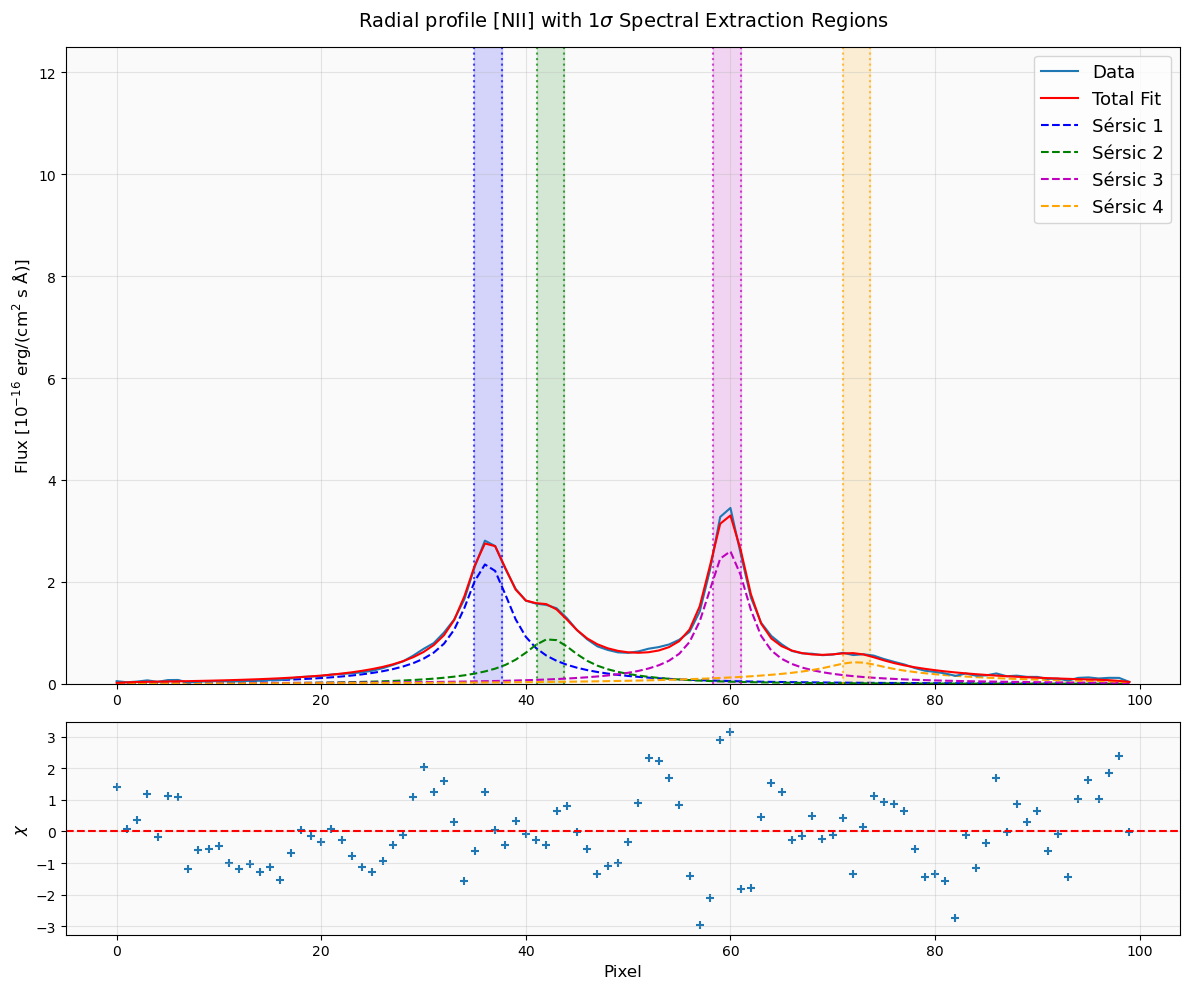

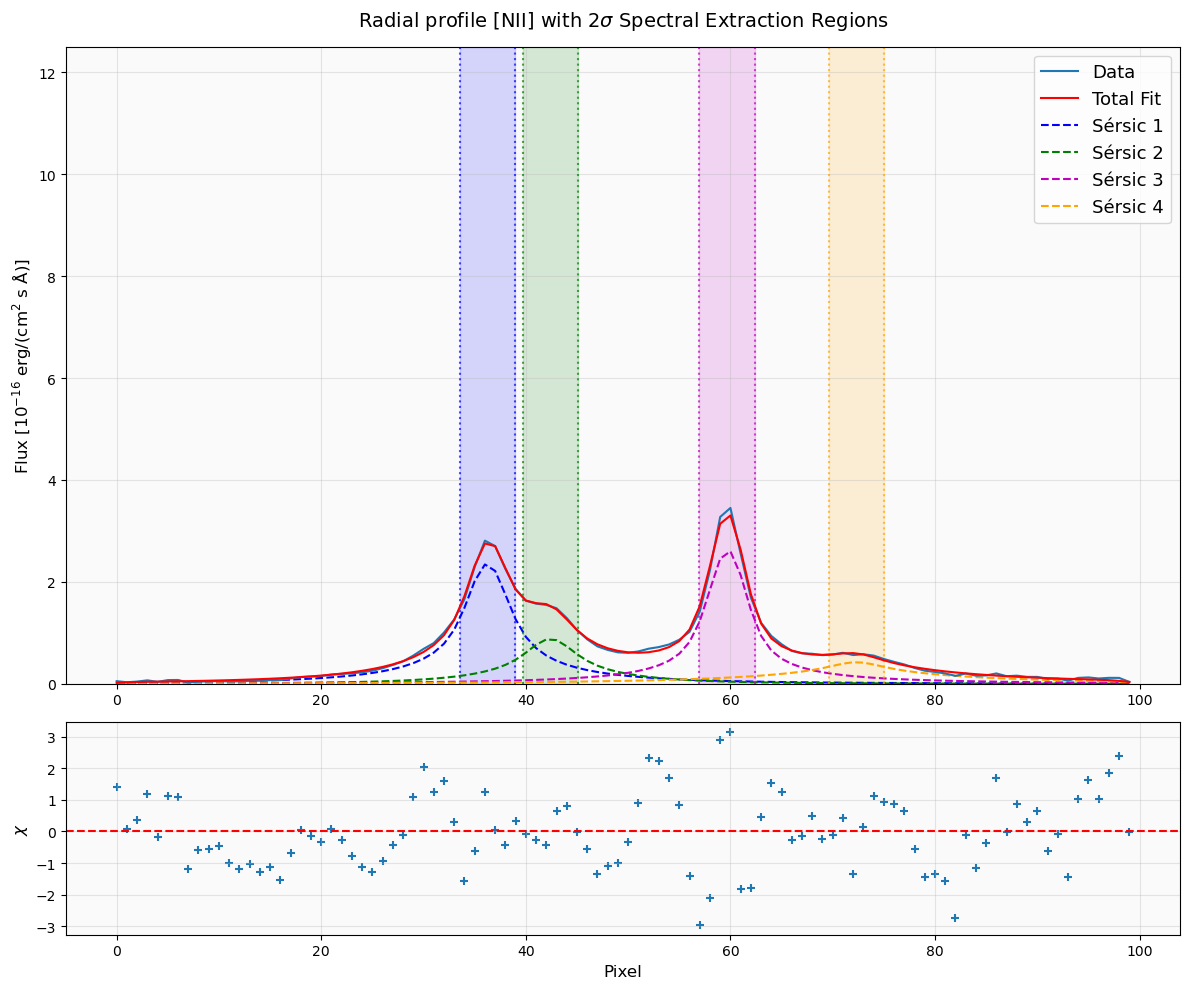

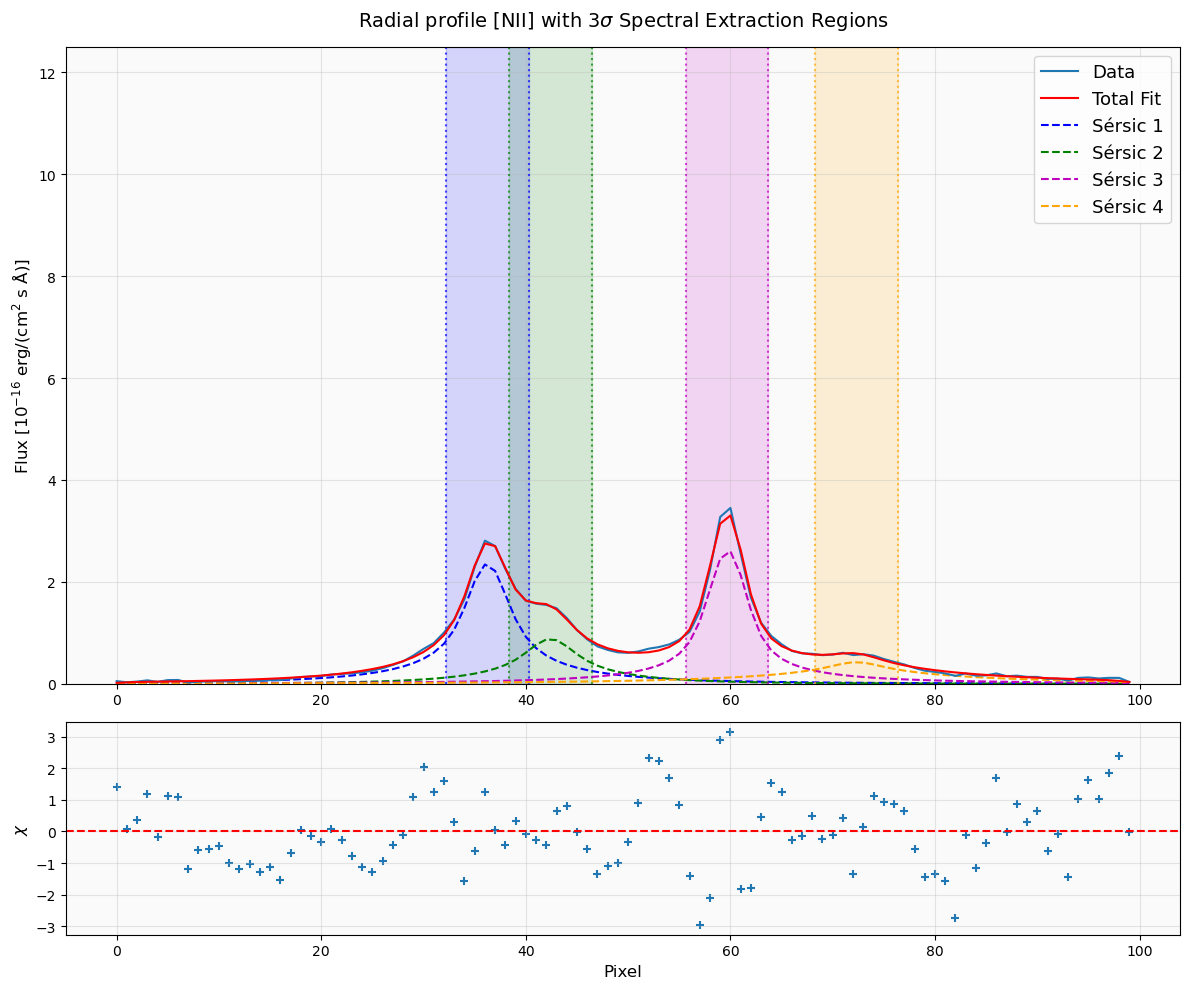

In [18]:
fit_NII = pd.read_csv("NII_fit.csv", index_col = 0)
plot_sigma_NII(1.0, x_axes, fit_NII, radial_profile_NII, radial_profile_error_NII, save_plot=True, output_dir="./")
plot_sigma_NII(2.0, x_axes, fit_NII, radial_profile_NII, radial_profile_error_NII, save_plot=True, output_dir="./")
plot_sigma_NII(3.0, x_axes, fit_NII, radial_profile_NII, radial_profile_error_NII, save_plot=True, output_dir="./")

## SII

Text(0.5, 1.0, '[SII]')

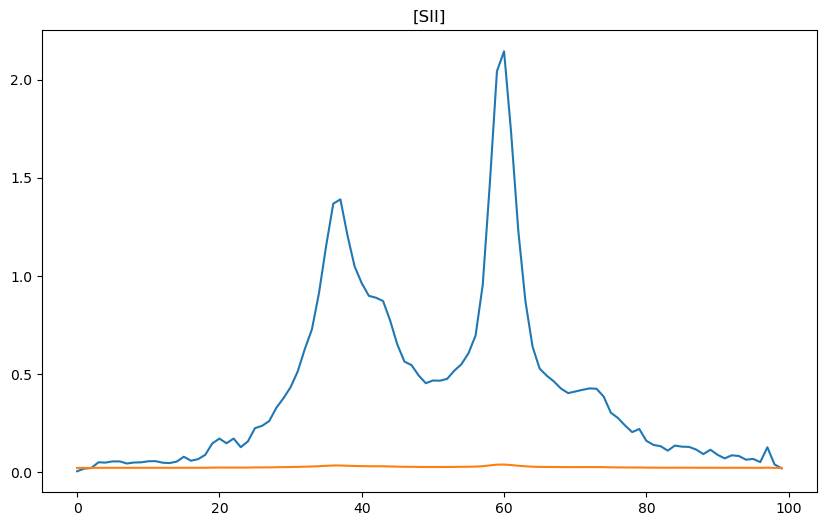

In [19]:
mask_SII = (wavelenghts > l_SII-8)*(wavelenghts < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [25]:
def plot_sigma_SII(sigma_extraction, x_axes, fit, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(xgrid, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].plot(x_axes, radial_profile, label='Data', zorder=3)
    ax[0].plot(xgrid, y_fit, 'r', label='Total Fit', zorder=3)
    
    colors = ['b', 'g', 'm', 'orange']  
    components = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
    
    for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(xgrid, np.array(fit[comp_name]))
        ax[0].plot(xgrid, y_comp, '--', color=color,  
                  label=f'Sérsic {i+1}')
        
        params = fit[comp_name]
        center = params[3] 
        
        left_region = center - sigma_extraction * sigma 
        right_region = center + sigma_extraction * sigma 
        
        ax[0].axvspan(left_region, right_region, alpha=0.15, color=color, zorder=1)
        
        ax[0].axvline(left_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(right_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Genera automaticamente il titolo
    sigma_text = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}"
    title = f"Radial profile [SII] with {sigma_text}$\\sigma$ Spectral Extraction Regions"
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    ax[0].set_ylim(0, 5)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"SII_{sigma_str}sigma.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_11440\1631834991.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center = params[3]


Plot salvato come: ./SII_1sigma.png
Plot salvato come: ./SII_2sigma.png
Plot salvato come: ./SII_3sigma.png


(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Radial profile [SII] with 3$\\sigma$ Spectral Extraction Regions'}, ylabel='Flux [$10^{-16}$ erg/(cm$^2$ s Å)]'>,
        <Axes: xlabel='Pixel', ylabel='$\\chi$'>], dtype=object))

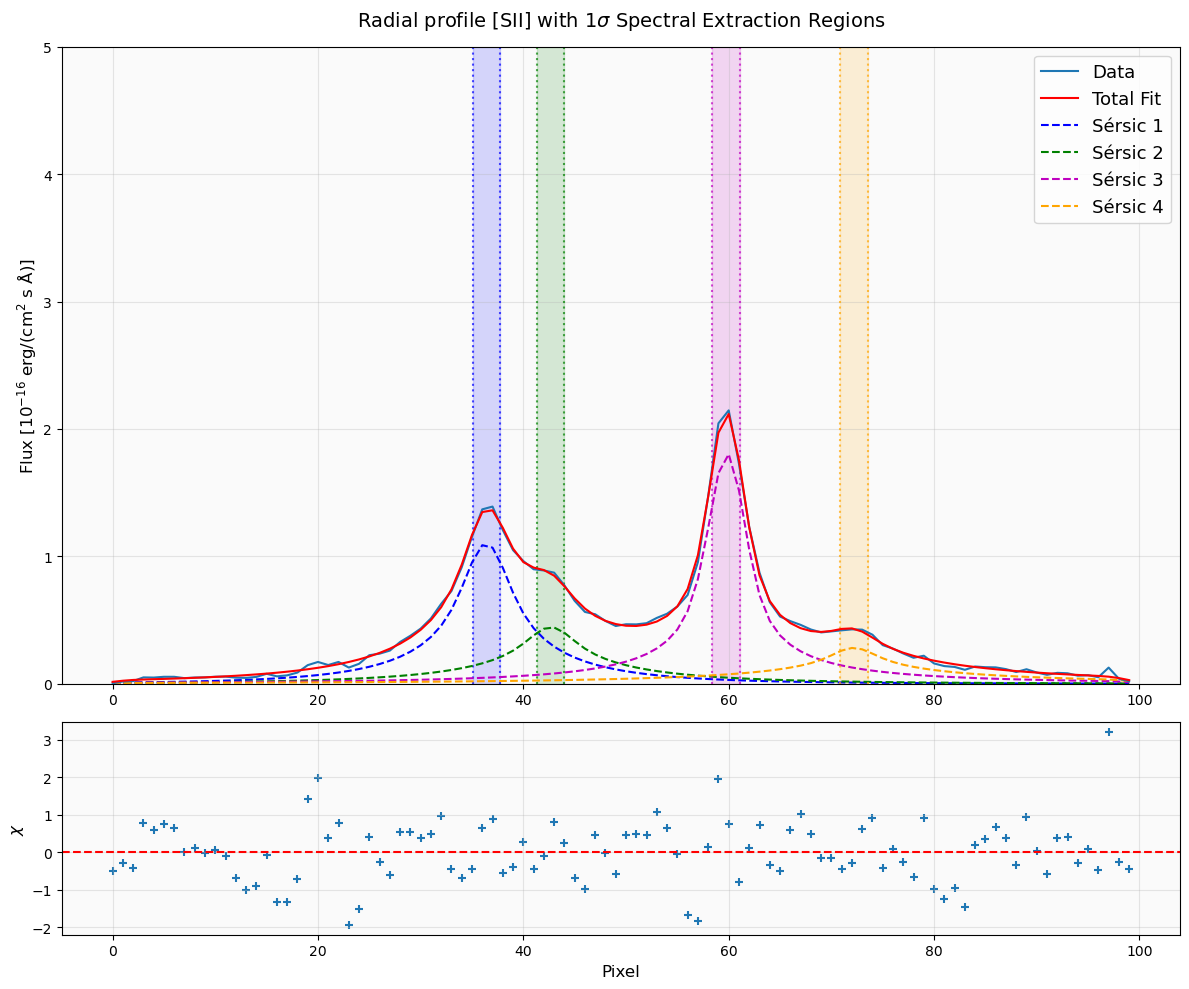

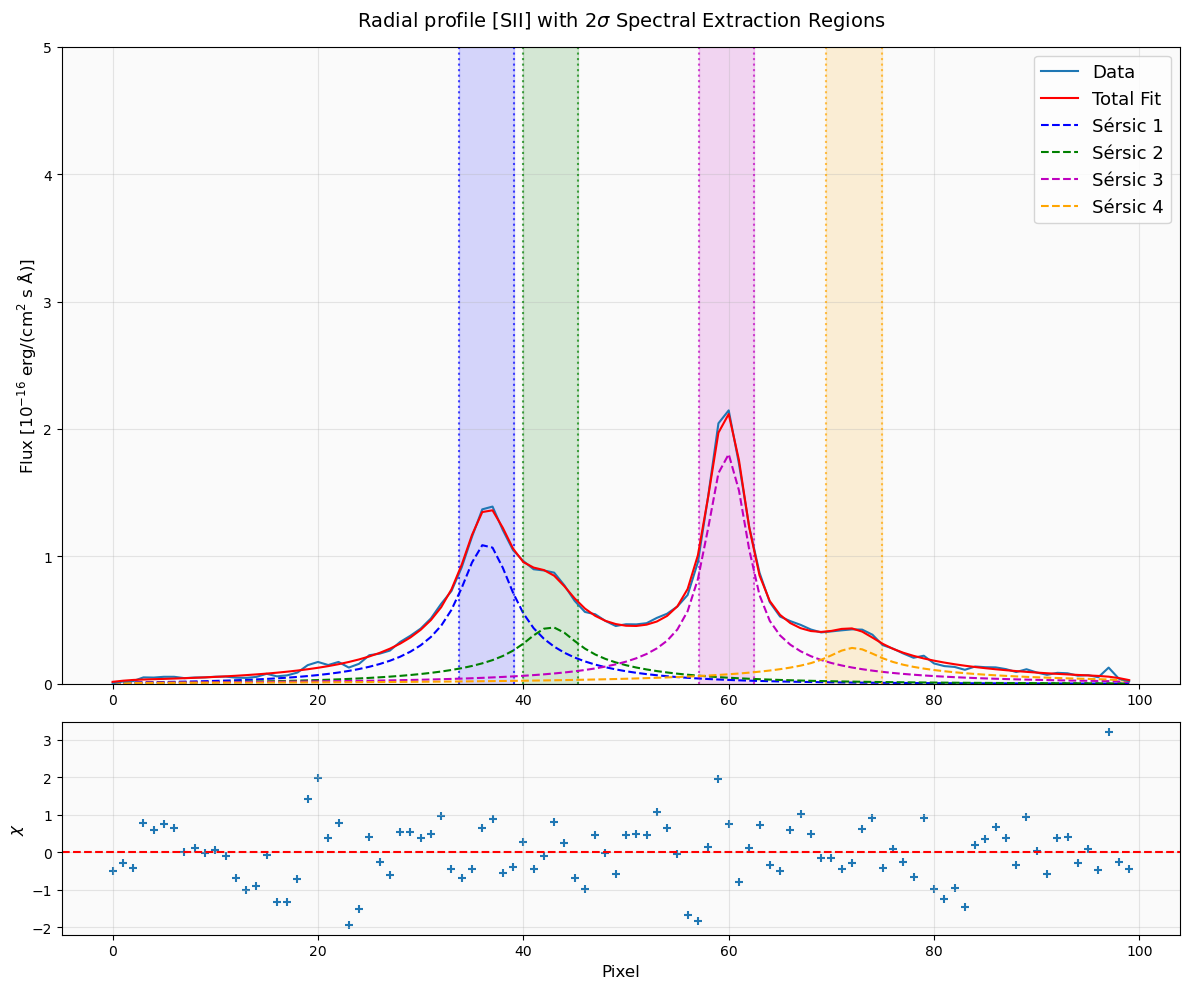

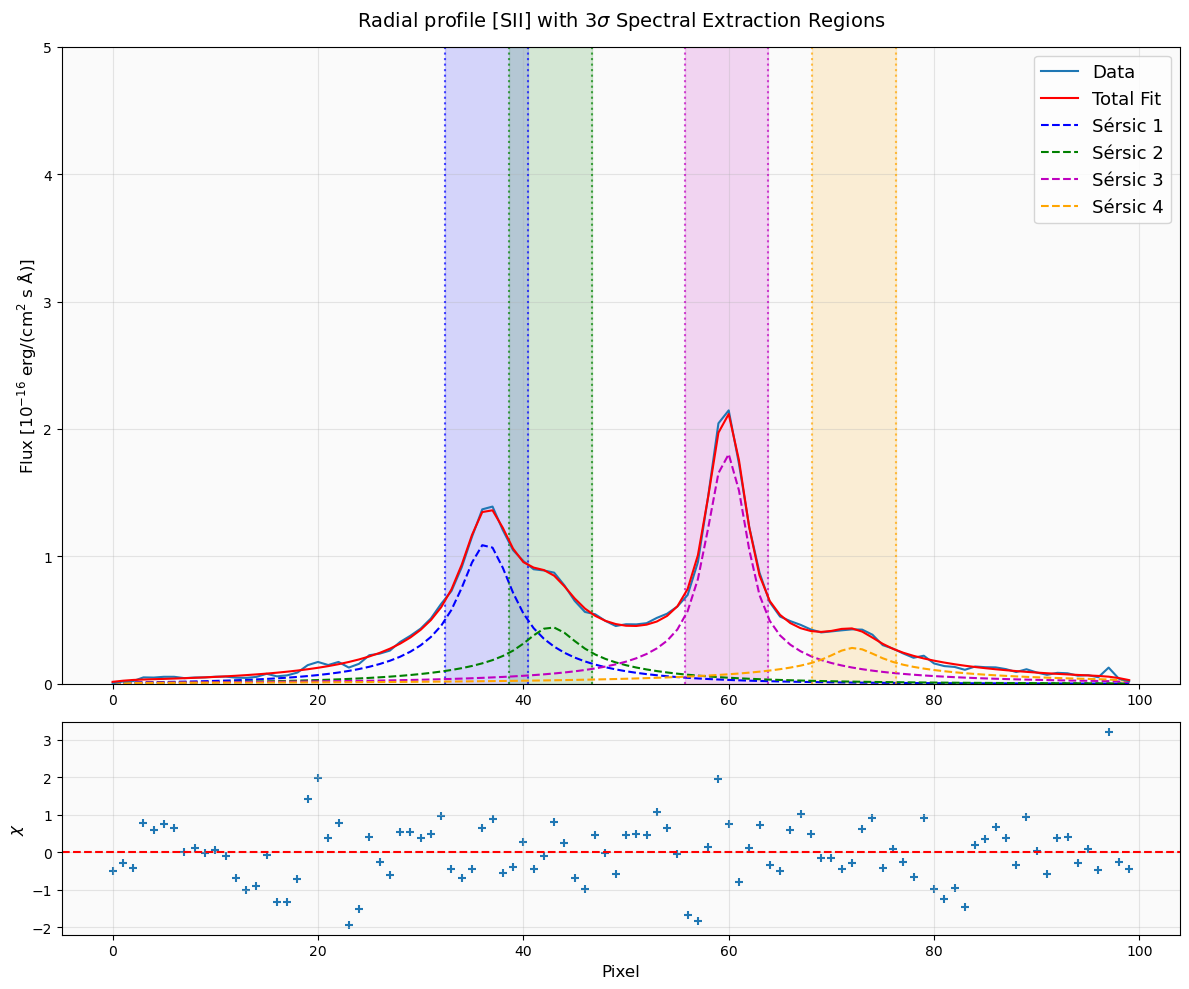

In [26]:
fit_SII = pd.read_csv("SII_fit.csv", index_col = 0)
plot_sigma_SII(1.0, x_axes, fit_SII, radial_profile_SII, radial_profile_error_SII, save_plot=True, output_dir="./")
plot_sigma_SII(2.0, x_axes, fit_SII, radial_profile_SII, radial_profile_error_SII, save_plot=True, output_dir="./")
plot_sigma_SII(3.0, x_axes, fit_SII, radial_profile_SII, radial_profile_error_SII, save_plot=True, output_dir="./")

## OIII

Text(0.5, 1.0, '[OIII]')

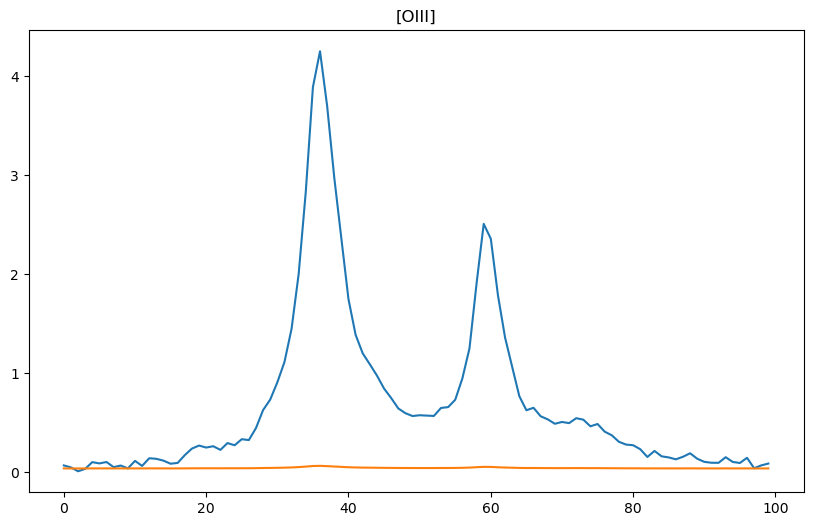

In [22]:
mask_OIII = (wavelenghts > l_OIII-8)*(wavelenghts < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [23]:
def plot_sigma_OIII(sigma_extraction, x_axes, fit, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(xgrid, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].plot(x_axes, radial_profile, label='Data', zorder=3)
    ax[0].plot(xgrid, y_fit, 'r', label='Total Fit', zorder=3)
    
    colors = ['b', 'g', 'm', 'orange']  
    components = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
    
    for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(xgrid, np.array(fit[comp_name]))
        ax[0].plot(xgrid, y_comp, '--', color=color,  
                  label=f'Sérsic {i+1}')
        
        params = fit[comp_name]
        center = params[3] 
        
        left_region = center - sigma_extraction * sigma 
        right_region = center + sigma_extraction * sigma 
        
        ax[0].axvspan(left_region, right_region, alpha=0.15, color=color, zorder=1)
        
        ax[0].axvline(left_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(right_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Genera automaticamente il titolo
    sigma_text = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}"
    title = f"Radial profile [OIII] with {sigma_text}$\\sigma$ Spectral Extraction Regions"
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    ax[0].set_ylim(0, 12.5)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"OIII_{sigma_str}sigma.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_11440\3250028813.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center = params[3]


Plot salvato come: ./OIII_1sigma.png
Plot salvato come: ./OIII_2sigma.png
Plot salvato come: ./OIII_3sigma.png


(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Radial profile [OIII] with 3$\\sigma$ Spectral Extraction Regions'}, ylabel='Flux [$10^{-16}$ erg/(cm$^2$ s Å)]'>,
        <Axes: xlabel='Pixel', ylabel='$\\chi$'>], dtype=object))

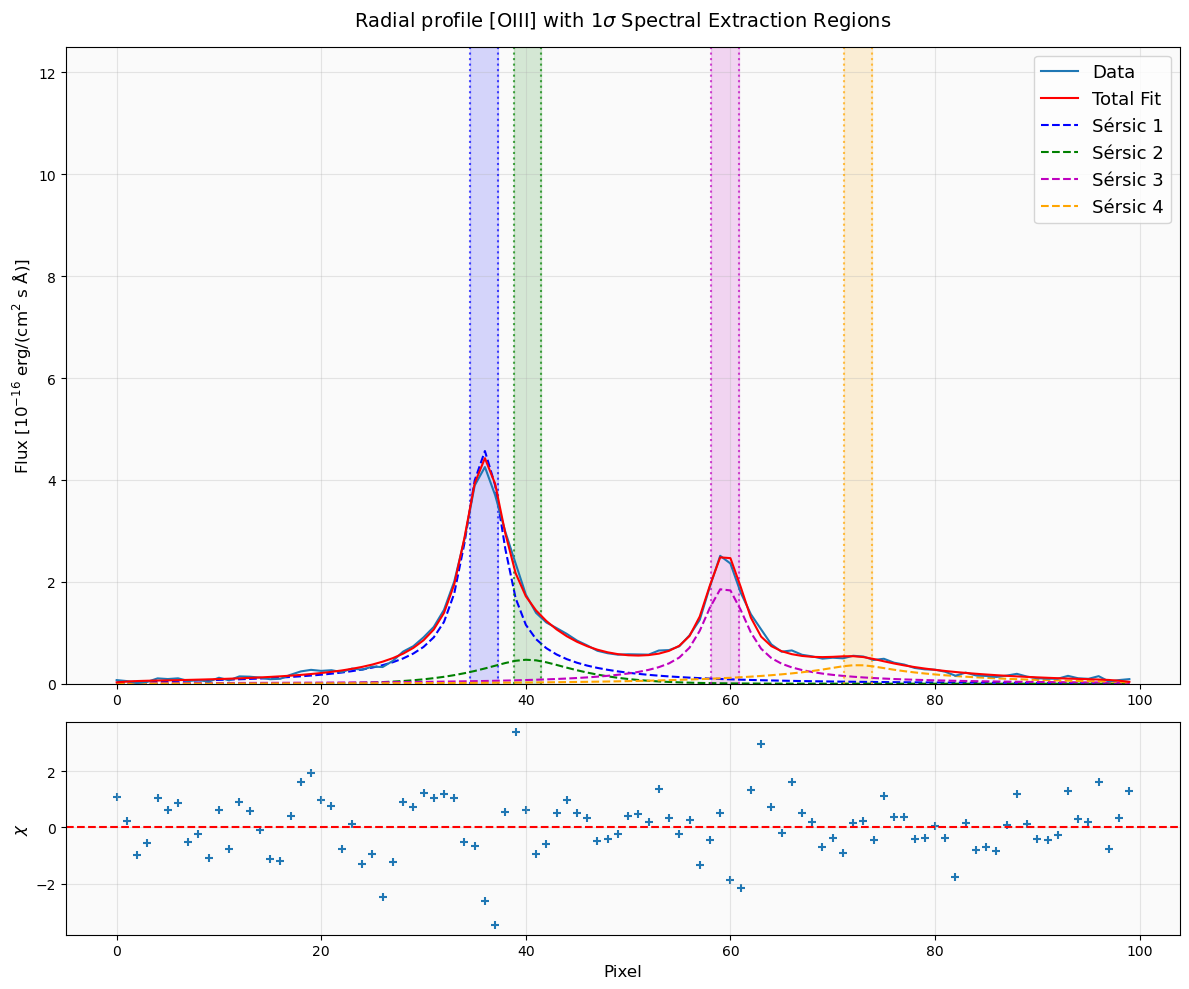

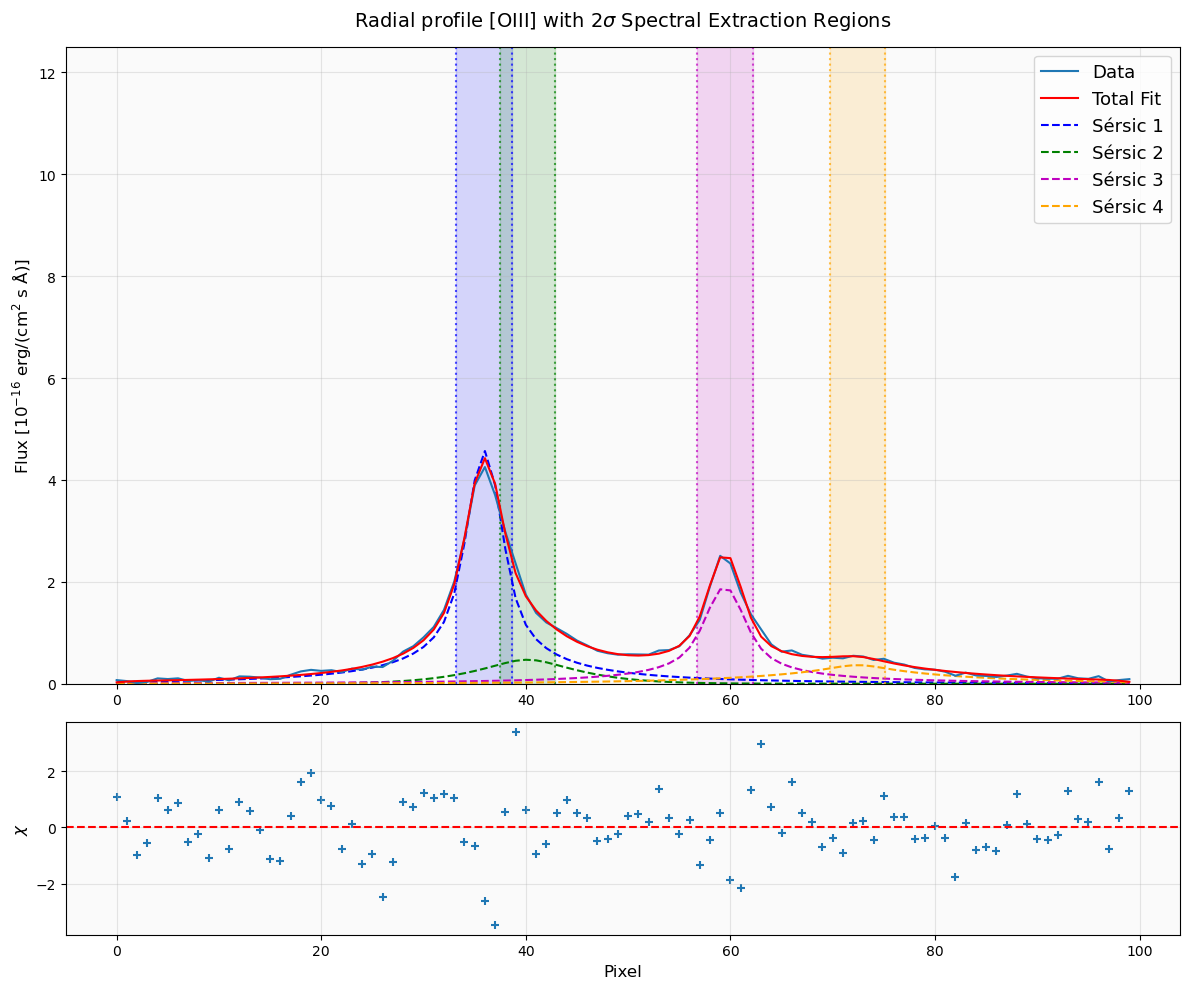

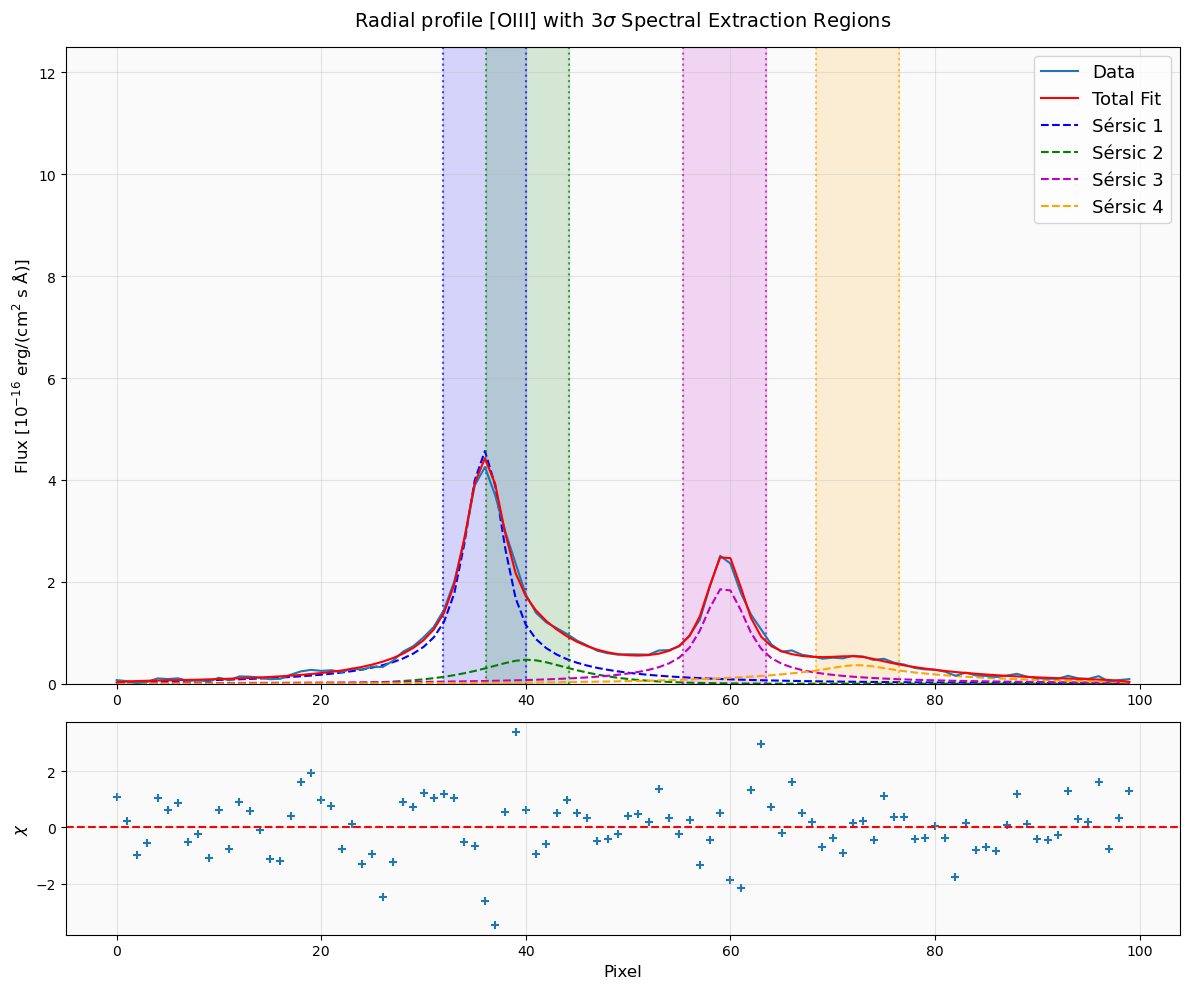

In [24]:
fit_OIII = pd.read_csv("OIII_fit.csv", index_col = 0)
plot_sigma_OIII(1.0, x_axes, fit_OIII, radial_profile_OIII, radial_profile_error_OIII, save_plot=True, output_dir="./")
plot_sigma_OIII(2.0, x_axes, fit_OIII, radial_profile_OIII, radial_profile_error_OIII, save_plot=True, output_dir="./")
plot_sigma_OIII(3.0, x_axes, fit_OIII, radial_profile_OIII, radial_profile_error_OIII, save_plot=True, output_dir="./")